# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset yang digunakan pada eksperimen ini adalah credit-g atau Statlog German Credit Data. Dataset ini digunakan untuk membangun model klasifikasi risiko kredit berdasarkan karakteristik pemohon kredit, seperti status rekening, durasi kredit, riwayat kredit, tujuan kredit, jumlah kredit, status pekerjaan, dan beberapa atribut lainnya.

Target klasifikasi pada dataset ini adalah credit_risk, yaitu kategori risiko kredit yang terdiri dari good dan bad. Pada tahap preprocessing, label good akan dikonversi menjadi 1, sedangkan label bad akan dikonversi menjadi 0 agar dapat digunakan oleh algoritma machine learning berbasis Scikit-Learn.

Dataset ini dipilih karena sesuai dengan studi kasus credit scoring dan memiliki kombinasi fitur numerik serta kategorikal. Oleh karena itu, proses preprocessing yang dilakukan meliputi pembersihan nama kolom, pengecekan missing value, pengecekan data duplikat, encoding fitur kategorikal, standardisasi fitur numerik, dan pembagian data menjadi data latih serta data uji.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
RAW_DIR = "credit_scoring_raw"
RAW_PATH = os.path.join(RAW_DIR, "credit_g.csv")

os.makedirs(RAW_DIR, exist_ok=True)

def clean_column_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[^a-zA-Z0-9_]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.strip("_")

credit_data = fetch_openml(data_id=31, as_frame=True)
df = credit_data.frame.copy()

df.columns = [clean_column_name(col) for col in df.columns]

if "class" in df.columns:
    df = df.rename(columns={"class": "credit_risk"})

df.to_csv(RAW_PATH, index=False)

print("Dataset berhasil dimuat dan disimpan.")
print("Lokasi raw dataset:", RAW_PATH)
print("Shape dataset:", df.shape)

df.head()

Dataset berhasil dimuat dan disimpan.
Lokasi raw dataset: credit_scoring_raw/credit_g.csv
Shape dataset: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,credit_risk
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housin

(1000, 21)


Lima data pertama:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,credit_risk
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad



Statistik deskriptif fitur numerik:


...

,0
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0



Jumlah data duplikat:


np.int64(0)


Distribusi target:


,count
credit_risk,
good,700
bad,300


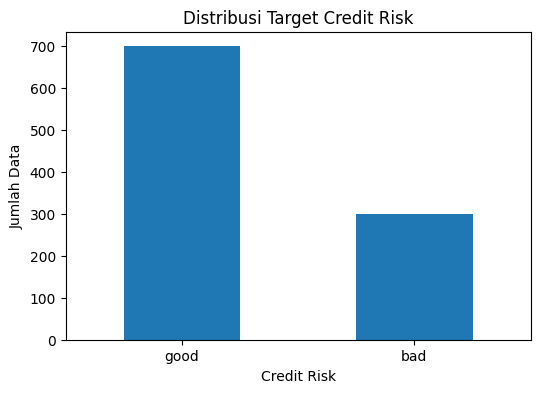

Kolom numerik: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Kolom kategorikal: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


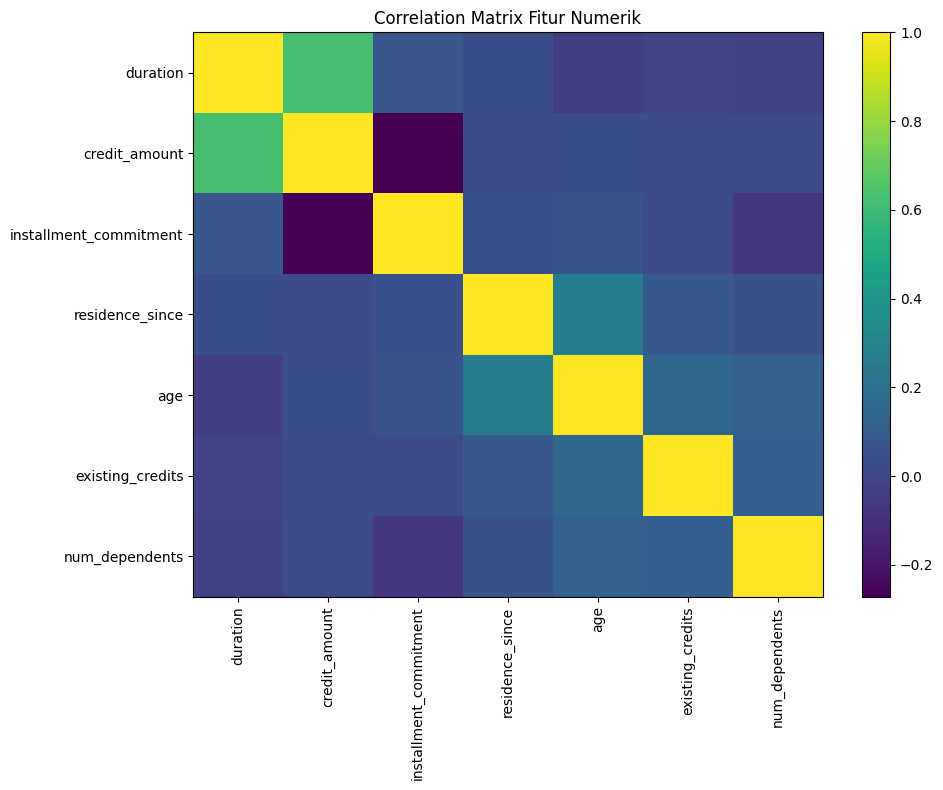

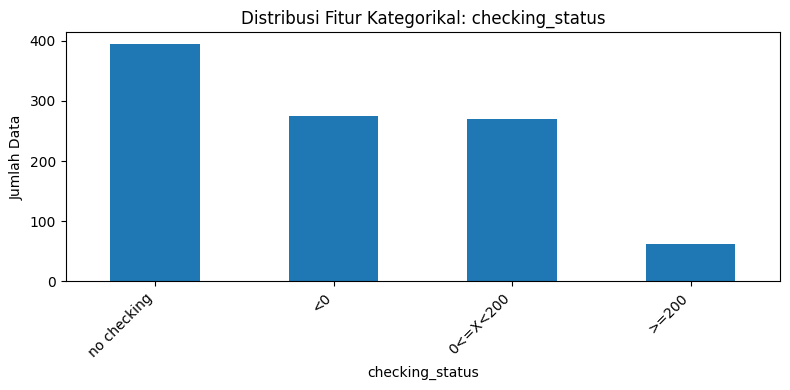

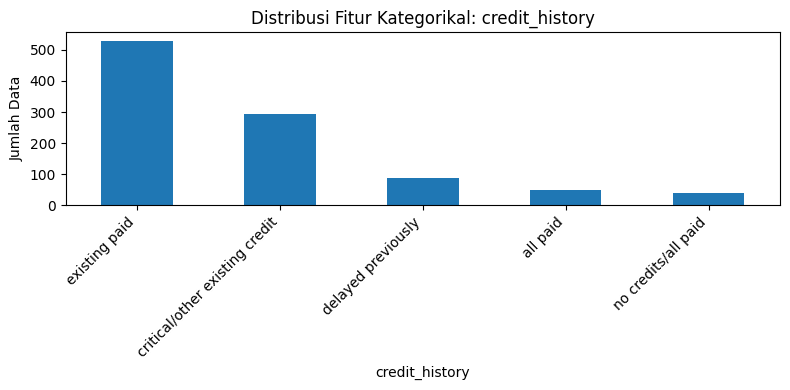

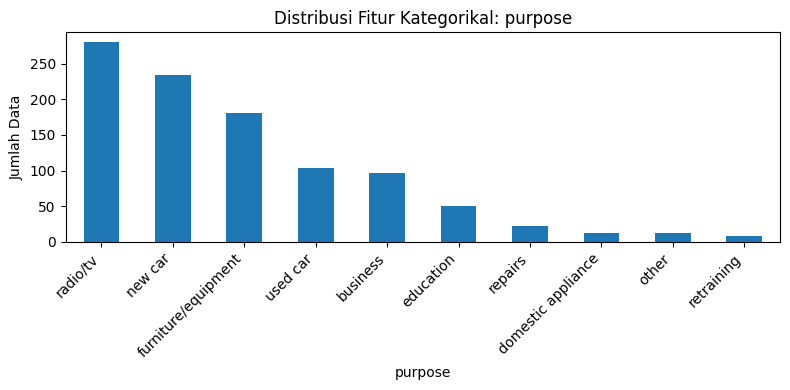

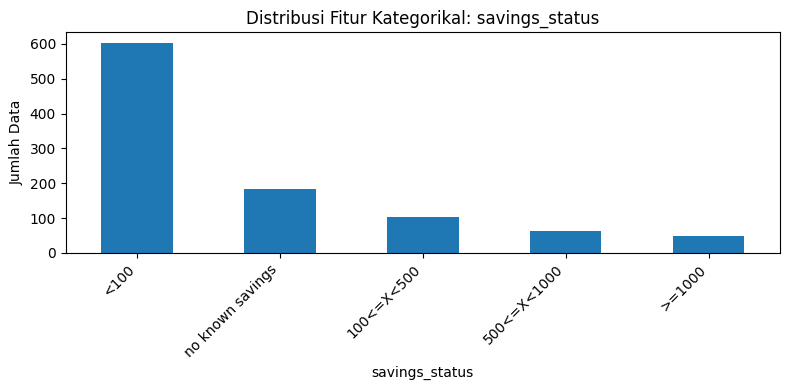

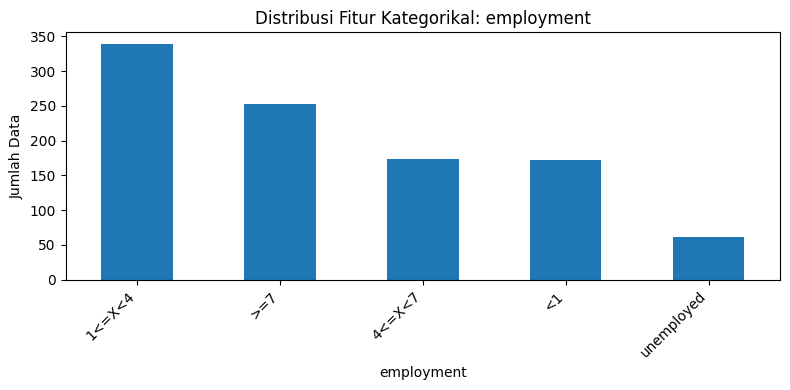

In [3]:
print("Informasi Dataset:")
df.info()

print("\nJumlah baris dan kolom:")
display(df.shape)

print("\nLima data pertama:")
display(df.head())

print("\nStatistik deskriptif fitur numerik:")
display(df.describe())

print("\nJumlah missing value per kolom:")
display(df.isnull().sum())

print("\nJumlah data duplikat:")
display(df.duplicated().sum())

print("\nDistribusi target:")
display(df["credit_risk"].value_counts())

plt.figure(figsize=(6, 4))
df["credit_risk"].value_counts().plot(kind="bar")
plt.title("Distribusi Target Credit Risk")
plt.xlabel("Credit Risk")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

if "credit_risk" in categorical_cols:
    categorical_cols.remove("credit_risk")

print("Kolom numerik:", numeric_cols)
print("Kolom kategorikal:", categorical_cols)

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix Fitur Numerik")
    plt.tight_layout()
    plt.show()

for col in categorical_cols[:5]:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(10).plot(kind="bar")
    plt.title(f"Distribusi Fitur Kategorikal: {col}")
    plt.xlabel(col)
    plt.ylabel("Jumlah Data")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
OUTPUT_DIR = "preprocessing/credit_scoring_preprocessing"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_COL = "credit_risk"

df_processed = df.copy()
df_processed = df_processed.drop_duplicates()

df_processed[TARGET_COL] = df_processed[TARGET_COL].astype(str).str.lower()

target_mapping = {
    "good": 1,
    "bad": 0,
    "1": 1,
    "2": 0
}

df_processed[TARGET_COL] = df_processed[TARGET_COL].map(target_mapping)

if df_processed[TARGET_COL].isnull().sum() > 0:
    raise ValueError("Target masih memiliki nilai yang tidak berhasil dipetakan.")

X = df_processed.drop(columns=[TARGET_COL])
y = df_processed[TARGET_COL]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
feature_names = [clean_column_name(col) for col in feature_names]

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

y_train_df = pd.DataFrame({"credit_risk": y_train.reset_index(drop=True)})
y_test_df = pd.DataFrame({"credit_risk": y_test.reset_index(drop=True)})

train_combined = pd.concat([X_train_df, y_train_df], axis=1)
test_combined = pd.concat([X_test_df, y_test_df], axis=1)
full_preprocessed = pd.concat([train_combined, test_combined], axis=0, ignore_index=True)

X_train_df.to_csv(os.path.join(OUTPUT_DIR, "X_train.csv"), index=False)
X_test_df.to_csv(os.path.join(OUTPUT_DIR, "X_test.csv"), index=False)
y_train_df.to_csv(os.path.join(OUTPUT_DIR, "y_train.csv"), index=False)
y_test_df.to_csv(os.path.join(OUTPUT_DIR, "y_test.csv"), index=False)
full_preprocessed.to_csv(os.path.join(OUTPUT_DIR, "credit_scoring_preprocessed.csv"), index=False)

joblib.dump(preprocessor, os.path.join(OUTPUT_DIR, "preprocessor.joblib"))

metadata = {
    "dataset_name": "credit-g / Statlog German Credit Data",
    "source": "OpenML data_id=31, originally from UCI Machine Learning Repository",
    "raw_shape": df.shape,
    "processed_shape": full_preprocessed.shape,
    "train_shape": X_train_df.shape,
    "test_shape": X_test_df.shape,
    "target_column": TARGET_COL,
    "target_mapping": target_mapping,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "random_state": 42,
    "test_size": 0.2
}

with open(os.path.join(OUTPUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("Preprocessing selesai.")
print("Output folder:", OUTPUT_DIR)
print("Shape X_train:", X_train_df.shape)
print("Shape X_test:", X_test_df.shape)

display(full_preprocessed.head())

Preprocessing selesai.
Output folder: preprocessing/credit_scoring_preprocessing
Shape X_train: (800, 61)
Shape X_test: (200, 61)


,num_duration,num_credit_amount,num_installment_commitment,num_residence_since,num_age,num_existing_credits,num_num_dependents,cat_checking_status_0_x_200,cat_checking_status_0,cat_checking_status_200,cat_checking_status_no_checking,cat_credit_history_all_paid,cat_credit_history_critical_other_existing_credit,cat_credit_history_delayed_previously,cat_credit_history_existing_paid,cat_credit_history_no_credits_all_paid,cat_purpose_business,cat_purpose_domestic_appliance,cat_purpose_education,cat_purpose_furniture_equipment,cat_purpose_new_car,cat_purpose_other,cat_purpose_radio_tv,cat_purpose_repairs,cat_purpose_retraining,cat_purpose_used_car,cat_savings_status_100_x_500,cat_savings_status_500_x_1000,cat_savings_status_100,cat_savings_status_1000,cat_savings_status_no_known_savings,cat_employment_1_x_4,cat_employment_4_x_7,cat_employment_1,cat_employment_7,cat_employment_unemployed,cat_personal_status_female_div_dep_mar,cat_personal_status_male_div_sep,cat_personal_status_male_mar_wid,cat_personal_status_male_single,cat_other_parties_co_applicant,cat_other_parties_guarantor,cat_other_parties_none,cat_property_magnitude_car,cat_property_magnitude_life_insurance,cat_property_magnitude_no_known_property,cat_property_magnitude_real_estate,cat_other_payment_plans_bank,cat_other_payment_plans_none,cat_other_payment_plans_stores,cat_housing_for_free,cat_housing_own,cat_housing_rent,cat_job_high_qualif_self_emp_mgmt,cat_job_skilled,cat_job_unemp_unskilled_non_res,cat_job_unskilled_resident,cat_own_telephone_none,cat_own_telephone_yes,cat_foreign_worker_no,cat_foreign_worker_yes,credit_risk
0,0.755149,0.485384,0.905268,1.044365,-0.825479,-0.719852,-0.442509,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1
1,0.755149,-0.246578,0.905268,-0.758207,0.493705,1.035885,-0.442509,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1
2,-0.726746,-0.584573,-1.797024,-1.659492,-1.177262,-0.719852,-0.442509,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1
3,0.014201,0.285331,-0.896260,0.143079,-0.033969,-0.719852,-0.442509,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1
4,-0.973728,-0.319522,-0.896260,1.044365,-1.177262,-0.719852,-0.442509,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1
